In [1]:
import numpy as np
from matplotlib import pyplot as plt

In [2]:
test_ps = np.load('../data_train/sim1168_ps2d.npz')
k_perp = test_ps['k_perp']
k_par = test_ps['k_par']
frequencies = test_ps['frequencies']

In [3]:
PS1_3 = np.loadtxt('./PS1/Pk_PS1_151.0_165.9.txt')
PS1_2 = np.loadtxt('./PS1/Pk_PS1_166.0_180.9.txt')
PS1_1 = np.loadtxt('./PS1/Pk_PS1_181.0_195.9.txt')

PS2_3 = np.loadtxt('./PS2/Pk_PS2_151.0_165.9.txt')
PS2_2 = np.loadtxt('./PS2/Pk_PS2_166.0_180.9.txt')
PS2_1 = np.loadtxt('./PS2/Pk_PS2_181.0_195.9.txt')

mean_ps_151 = np.loadtxt('/lustre/fswork/projects/rech/ybg/uuv28wh/noise_data/Pk_PS_averaged_noise_151.0_165.9.txt')
mean_ps_166 = np.loadtxt('/lustre/fswork/projects/rech/ybg/uuv28wh/noise_data/Pk_PS_averaged_noise_166.0_180.9.txt')
mean_ps_181 = np.loadtxt('/lustre/fswork/projects/rech/ybg/uuv28wh/noise_data/Pk_PS_averaged_noise_181.0_195.9.txt')
std_ps_151 = np.loadtxt('/lustre/fswork/projects/rech/ybg/uuv28wh/noise_data/noise_std_bin3')
std_ps_166 = np.loadtxt('/lustre/fswork/projects/rech/ybg/uuv28wh/noise_data/noise_std_bin2')
std_ps_181 = np.loadtxt('/lustre/fswork/projects/rech/ybg/uuv28wh/noise_data/noise_std_bin1')

In [4]:
PS1 = np.stack([PS1_1, PS1_2, PS1_3], axis=0)
PS2 = np.stack([PS2_1, PS2_2, PS2_3], axis=0)
noise = np.stack([mean_ps_181, mean_ps_166, mean_ps_151], axis=0)

In [37]:
np.savez('./PS1/PS1.npz', power_spectra=PS1, frequencies=frequencies, k_perp=k_perp, k_par=k_par)
np.savez('./PS2/PS2.npz', power_spectra=PS2, frequencies=frequencies, k_perp=k_perp, k_par=k_par)
np.savez('./PS1/noise.npz', power_spectra=noise, frequencies=frequencies, k_perp=k_perp, k_par=k_par)

In [17]:
PS1 = np.load('./PS1/PS1.npz')['power_spectra']
noise = np.load('./PS1/noise.npz')['power_spectra']
PS2 = np.load('./PS2/PS2.npz')['power_spectra']


In [18]:
PS1_pure = PS1 - noise
PS2_pure = PS2 - noise

In [24]:
PS1_pure[PS1_pure<0] =1e-12
PS2_pure[PS2_pure<0] =1e-12

In [26]:
PS2_pure.min()

1e-12

In [27]:
np.savez('./PS1/PS1_pure.npz', power_spectra=PS1_pure, frequencies=frequencies, k_perp=k_perp, k_par=k_par)
np.savez('./PS2/PS2_pure.npz', power_spectra=PS2_pure, frequencies=frequencies, k_perp=k_perp, k_par=k_par)

In [30]:
PS1 = np.load('./PS1/PS1.npz')['power_spectra']
PS1_pure = np.load('./PS1/PS1_pure.npz')['power_spectra']
PS2 = np.load('./PS2/PS2.npz')['power_spectra']
PS2_pure = np.load('./PS2/PS2_pure.npz')['power_spectra']
k_perp = np.load('./PS1/PS1.npz')['k_perp']
k_par = np.load('./PS1/PS1.npz')['k_par']

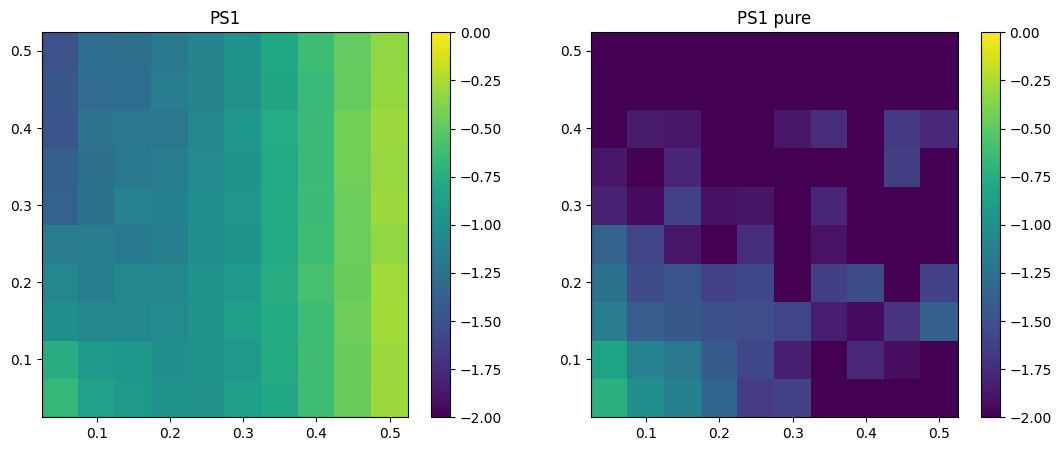

In [40]:
fig, ax = plt.subplots(1,2, figsize=(13,5))
im = ax[0].pcolor(k_perp, k_par, (np.log10(PS1[2])), vmin=-2, vmax=0)
im = ax[1].pcolor(k_perp, k_par, (np.log10(PS1_pure[2])), vmin=-2, vmax=0)
ax[0].set(title='PS1')
ax[1].set(title='PS1 pure')
plt.colorbar(im, ax=ax[0])
plt.colorbar(im, ax=ax[1])

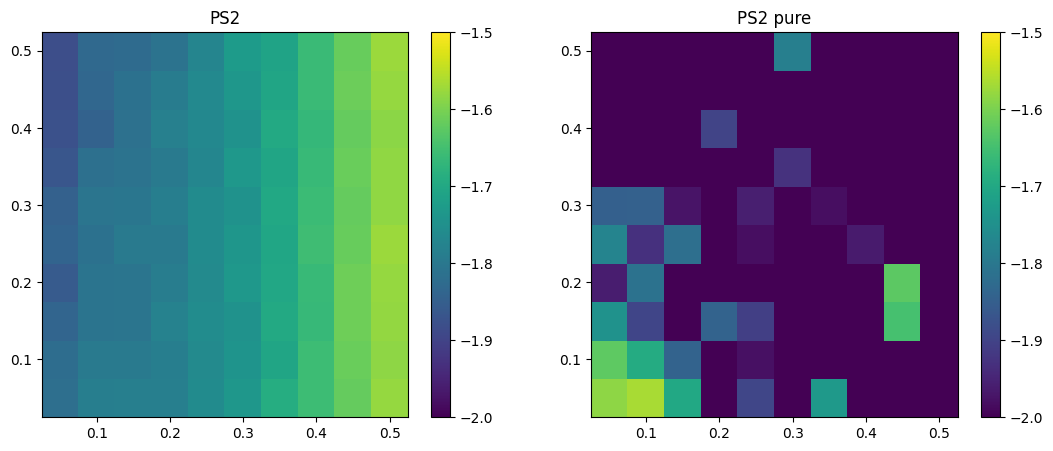

In [43]:
fig, ax = plt.subplots(1,2, figsize=(13,5))
im = ax[0].pcolor(k_perp, k_par, (np.log10(PS2[2])), vmin=-2, vmax=0)
im = ax[1].pcolor(k_perp, k_par, (np.log10(PS2_pure[2])), vmin=-2, vmax=-1.5)
ax[0].set(title='PS2')
ax[1].set(title='PS2 pure')
plt.colorbar(im, ax=ax[0])
plt.colorbar(im, ax=ax[1])

In [12]:
from astropy.io import fits
import numpy as np
from ipywidgets import interact
from matplotlib import pyplot as plt
posterior1 = './posterior_PS1.fits'

In [7]:
with fits.open(posterior1) as hdul:
    data = hdul[0].data
    print("data shape:", data.shape)

data shape: (100, 100, 100)


In [8]:
np.mean(noise_data)

1.0000000000000002e-06

In [13]:
def plot_slice(slice_index=0):
    plt.figure(figsize=(8, 8))
    plt.imshow(data[slice_index, :, :], cmap='viridis', origin='lower')
    plt.colorbar(label='Pixel Value')
    #plt.xlim(1000, 1040)
    #plt.ylim(1000, 1040)
    plt.title(f'Slice {slice_index}')
    plt.show()

# Create an interactive slider for the slice index
interact(plot_slice, slice_index=(0, data.shape[0]-1))

interactive(children=(IntSlider(value=0, description='slice_index', max=99), Output()), _dom_classes=('widget-…

<function __main__.plot_slice(slice_index=0)>

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # ensures 3D plotting support
from astropy.io import fits

def plot_fits_posterior_3d(fits_filename: str, threshold_fraction: float = 0.0001, savefig: str = None):
    """
    Load a 3D posterior from a FITS file and create a 3D scatter plot.
    
    Parameters:
        fits_filename (str): Path to the FITS file containing the 3D posterior.
        threshold_fraction (float): Only bins with a probability density above 
            threshold_fraction * max(probability) will be plotted.
            Default is 0.01 (i.e. 1% of the maximum value).
        savefig (str, optional): If provided, the figure will be saved to this filename.
    """
    # Load the FITS file
    with fits.open(fits_filename) as hdul:
        hdr = hdul[0].header
        data = hdul[0].data  # shape: (NAXIS3, NAXIS2, NAXIS1)
    
    # Extract header information for coordinate system
    nx = hdr['NAXIS1']
    ny = hdr['NAXIS2']
    nz = hdr['NAXIS3']
    
    CRVAL1, CDELT1 = hdr['CRVAL1'], hdr['CDELT1']
    CRVAL2, CDELT2 = hdr['CRVAL2'], hdr['CDELT2']
    CRVAL3, CDELT3 = hdr['CRVAL3'], hdr['CDELT3']
    
    # Construct coordinate arrays for each axis.
    # Note: FITS data ordering is (NAXIS3, NAXIS2, NAXIS1) corresponding to (z, y, x)
    x_coords = CRVAL1 + np.arange(nx) * CDELT1
    y_coords = CRVAL2 + np.arange(ny) * CDELT2
    z_coords = CRVAL3 + np.arange(nz) * CDELT3
    
    # Create index grids for the data array.
    # data shape is (nz, ny, nx)
    z_idx, y_idx, x_idx = np.indices((nz, ny, nx))
    
    # Map the indices to coordinates:
    x_vals = x_coords[x_idx]
    y_vals = y_coords[y_idx]
    z_vals = z_coords[z_idx]
    
    # Flatten the arrays for plotting.
    x_vals = x_vals.flatten()
    y_vals = y_vals.flatten()
    z_vals = z_vals.flatten()
    prob_vals = data.flatten()
    
    # Filter out low probability bins to reduce clutter.
    threshold = threshold_fraction * np.max(prob_vals)
    mask = prob_vals >= threshold
    
    # Create a 3D scatter plot.
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')
    sc = ax.scatter(x_vals[mask], y_vals[mask], z_vals[mask],
                    c=prob_vals[mask], cmap='viridis', marker='o', s=5)
    cbar = fig.colorbar(sc, ax=ax, pad=0.1)
    cbar.set_label('Posterior Probability Density')
    
    ax.set_xlabel('xH1')
    ax.set_ylabel('xH2')
    ax.set_zlabel('xH3')
    plt.title('3D Posterior Probability Distribution')
    
    if savefig:
        plt.savefig(savefig)
        print(f"3D plot saved to {savefig}")
    else:
        plt.show()

In [1]:
plot_fits_posterior_3d('posterior_PS1.fits', threshold_fraction=0.01, savefig='posterior_3d_plot.png')

NameError: name 'plot_fits_posterior_3d' is not defined